In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

def generate_demand():
    r = np.random.random()
    if r <= 0.1:
        return 1
    elif r <= 0.25:
        return 2
    elif r <= 0.6:
        return 3
    elif r <= 0.80:
        return 4
    elif r < 1:
        return 5

def generate_leadTime():
    r = np.random.random()
    if r <= 0.4:
        return 1
    elif r <= 0.75:
        return 2
    elif r < 1:
        return 3

cycle_len = 6
days = int(input("Number of days? "))
cycles = days // cycle_len

initialFirstFloor = 4
initialBasement = 30
maxFirstFloor = 10
maxBasement = 30

Days = [0]
FirstFloorBeginning = [initialFirstFloor]
BasementBeginning = [initialBasement]
Demand = [0]
FirstFloorEnding = [initialFirstFloor]
BasementEnding = [initialBasement]
ShortageFirstFloor = [0]
OrderQuanFirstFloor = [0]
OrderQuanBasement = [0]
LeadTime = [0]
AddAtDay = [0]
ComingOrders = [0] * (days + 1)

for i in range(1, days + 1):

    Days.append(i)
    # Basement Beginning
    BasementBeginning.append(max(BasementEnding[i-1] - OrderQuanFirstFloor[i-1] + ComingOrders[i], 0))

    # First Floor Beginning
    if FirstFloorEnding[i-1] == 0:
        FirstFloorBeginning.append(maxFirstFloor)
    else:
        FirstFloorBeginning.append(FirstFloorEnding[i-1])

    # Demand
    Demand.append(generate_demand())
    currentDemand = Demand[i]

    # First Floor Ending
    FirstFloorEnding.append(max(FirstFloorBeginning[i] - currentDemand - ShortageFirstFloor[i-1], 0))

    # Basement Ending
    BasementEnding.append(max(BasementBeginning[i], 0))

    # Shortage and Order Quantity
    if Demand[i] >= FirstFloorBeginning[i]:
        ShortageFirstFloor.append(currentDemand - FirstFloorBeginning[i])
        OrderQuanFirstFloor.append(maxFirstFloor)
    else:
        ShortageFirstFloor.append(0)
        OrderQuanFirstFloor.append(0)

    # Make Order at the end of every cycle
    if i % cycle_len == 0:  # Last day in cycle
        BasementQuanToAdd = maxBasement - BasementEnding[i] + OrderQuanFirstFloor[i]
        OrderQuanBasement.append(BasementQuanToAdd)
        LeadTime.append(generate_leadTime())
        FillingDay = i + LeadTime[i] + 1
        if FillingDay <= days:
            ComingOrders[FillingDay] += BasementQuanToAdd
            AddAtDay.append(FillingDay)
        else:
            AddAtDay.append(0)
    else:
        OrderQuanBasement.append(0)
        LeadTime.append(0)
        AddAtDay.append(0)

    Table = {
      "Days": Days,
      "FFBegin": FirstFloorBeginning,
      "B.Begin": BasementBeginning,
      "Demand": Demand,
      "FFEnd": FirstFloorEnding,
      "B.End": BasementEnding,
      "Shortage": ShortageFirstFloor,
      "QFF": OrderQuanFirstFloor,
      "Q.Base": OrderQuanBasement,
      #"AddedAt": AddAtDay,
      "LTime": LeadTime
    }

table = pd.DataFrame(Table)
table.drop(0, inplace=True)
print(table.head(100))


Number of days? 20
    Days  FFBegin  B.Begin  Demand  FFEnd  B.End  Shortage  QFF  Q.Base  LTime
1      1        4       30       4      0     30         0   10       0      0
2      2       10       20       3      7     20         0    0       0      0
3      3        7       20       3      4     20         0    0       0      0
4      4        4       20       5      0     20         1   10       0      0
5      5       10       10       4      5     10         0    0       0      0
6      6        5       10       3      2     10         0    0      35      2
7      7        2       10       5      0     10         3   10       0      0
8      8       10        0       2      5      0         0    0       0      0
9      9        5       35       3      2     35         0    0       0      0
10    10        2       35       4      0     35         2   10       0      0
11    11       10       25       4      4     25         0    0       0      0
12    12        4       25       

The Average of First Floor Ending:  2.14


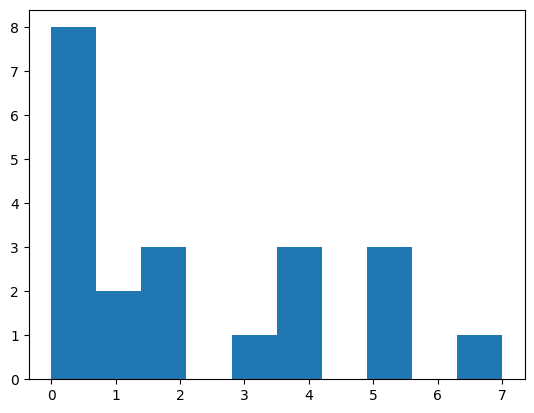

In [ ]:
# The Average of First Floor Ending & histogram
FirstFloorEnding_Avg = round(np.mean(FirstFloorEnding), 2)
plt.hist(FirstFloorEnding)
print("The Average of First Floor Ending: ", FirstFloorEnding_Avg)

The Average of Basement Ending:  23.81


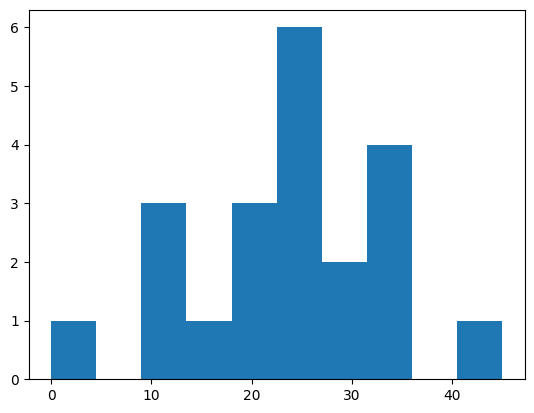

In [ ]:
# The Average of Basememnt Ending & histogram
BasementEnding_Avg = round(np.mean(BasementEnding), 2)
plt.hist(BasementEnding)
print("The Average of Basement Ending: ", BasementEnding_Avg)

In [ ]:
# The number of days when a shortage condition occurs
ShortageDays = 0
for i in ShortageFirstFloor:
    if i > 0:
        ShortageDays += 1
print("The number of days when a shortage condition occurs: ", ShortageDays, "Days")


The number of days when a shortage condition occurs:  6 Days


In [ ]:
#Does the theoretical average demand of boxes match the experimental one?

DWeights = [0.1, 0.15, 0.35, 0.2, 0.2]
Demands = [1, 2, 3, 4, 5]
TheoreticalDemand = 0
for i in range(len(DWeights)):
    TheoreticalDemand += DWeights[i] * Demands[i]
print("Theoretical demand is: ", TheoreticalDemand)

ExperimentalDemand = round(np.mean(Demand),2)
print("Experimental demand is: ", ExperimentalDemand)




Theoretical demand is:  3.25
Experimental demand is:  3.14


In [ ]:
#Does the theoretical average lead time of the lead time distribution match the experimental one?
LWeights = [0.4, 0.35, 0.25]
LeadTimes = [1, 2, 3]
TheoreticalLeadTime = 0
for i in range(len(LWeights)):
    TheoreticalLeadTime += LWeights[i] * LeadTimes[i]
print("Theoretical lead time is: ", TheoreticalLeadTime)

ExperimentalLeadTime = round(np.sum(LeadTime)/cycles,2)
print("Experimental lead time is: ", ExperimentalLeadTime)


Theoretical lead time is:  1.85
Experimental lead time is:  1.75


In [ ]:
# Is there a better value for the review period variable N to minimize the shortages of medical supplies boxes?

In [ ]:
# Is there a better value for the maximum capacity M of the basement inventory to minimize the shortages of medical supplies boxes?

In [ ]:
# More generic statistics
print("Table Mean:\n")
print(table.mean())
print("\nTable Median:\n")
print(table.median())
print("\nTable Variance:\n")
print(table.var())
print("\nTable Standard Deviation:\n")
print(table.std())

Table Mean:

Days        20.500
FFBegin      6.375
B.Begin     17.750
Demand       3.250
FFEnd        3.125
B.End       17.750
Shortage     0.250
QFF          3.250
Q.Base       2.750
LTime        0.325
dtype: float64

Table Median:

Days        20.5
FFBegin      6.0
B.Begin     20.0
Demand       3.0
FFEnd        3.0
B.End       20.0
Shortage     0.0
QFF          0.0
Q.Base       0.0
LTime        0.0
dtype: float64

Table Variance:

Days        136.666667
FFBegin       9.676282
B.Begin      89.679487
Demand        1.576923
FFEnd         8.009615
B.End        89.679487
Shortage      0.346154
QFF          22.500000
Q.Base       51.217949
LTime         0.737821
dtype: float64

Table Standard Deviation:

Days        11.690452
FFBegin      3.110672
B.Begin      9.469925
Demand       1.255756
FFEnd        2.830126
B.End        9.469925
Shortage     0.588348
QFF          4.743416
Q.Base       7.156672
LTime        0.858965
dtype: float64
